In [1]:
# ================================================
# Chest X-ray Pneumonia Classification
# Notebook 1: Setup & Data Preparation
# ================================================

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", "GPU" if torch.cuda.is_available() else "CPU (laptop mode)")

PyTorch version: 2.12.0+cpu
GPU available: False
Device: CPU (laptop mode)


In [4]:
# Base path to your dataset
DATA_DIR = r"C:\Users\maria\Documents\chest_xray_project\data\chest_xray"

# Paths to each split
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# Check folders exist
for split, path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    normal    = len(os.listdir(os.path.join(path, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(path, "PNEUMONIA")))
    print(f"{split}: {normal} NORMAL, {pneumonia} PNEUMONIA images")

Train: 1341 NORMAL, 3875 PNEUMONIA images
Val: 8 NORMAL, 8 PNEUMONIA images
Test: 234 NORMAL, 390 PNEUMONIA images


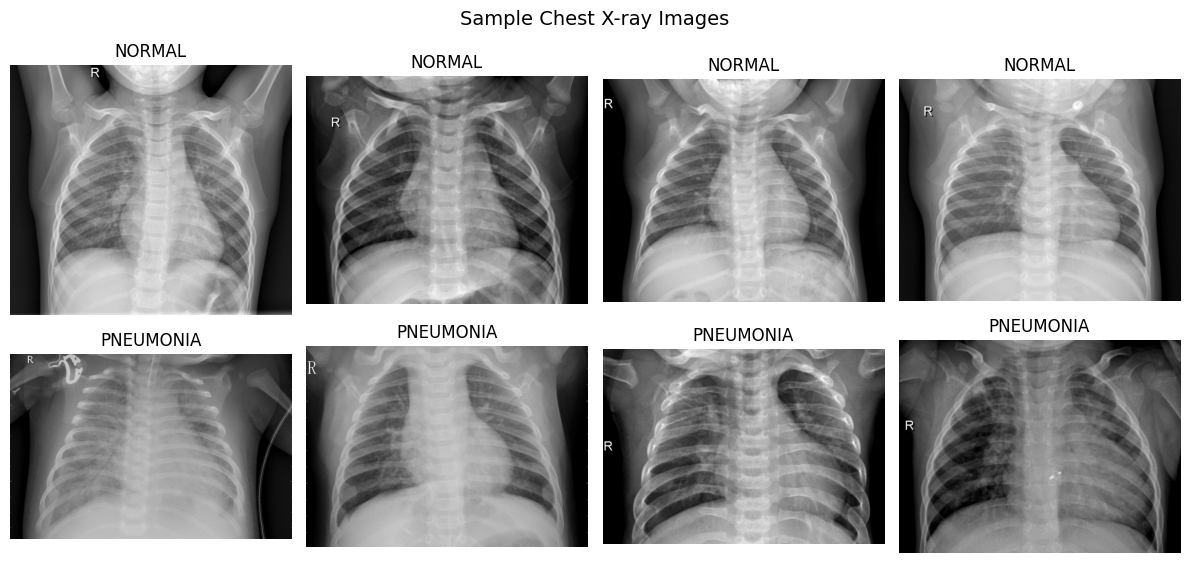

In [5]:
# Let's look at some real X-ray images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Sample Chest X-ray Images", fontsize=14)

for i, label in enumerate(["NORMAL", "PNEUMONIA"]):
    folder = os.path.join(TRAIN_DIR, label)
    images = os.listdir(folder)[:4]  # just first 4 images
    
    for j, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path).convert("RGB")
        axes[i][j].imshow(img, cmap="gray")
        axes[i][j].set_title(label)
        axes[i][j].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# ================================================
# Image Transformations
# ================================================

# For training - we add augmentation to make model more robust
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),        # resize all images to 224x224
    transforms.RandomHorizontalFlip(),    # randomly flip image (augmentation)
    transforms.RandomRotation(10),        # randomly rotate up to 10 degrees
    transforms.ToTensor(),                # convert image to numbers (tensor)
    transforms.Normalize(                 # normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# For validation and test - no augmentation, just resize and normalize
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined successfully!")

Transforms defined successfully!


In [7]:
# ================================================
# Load Datasets
# ================================================

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print(f"\nTraining samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Classes: ['NORMAL', 'PNEUMONIA']
Class to index: {'NORMAL': 0, 'PNEUMONIA': 1}

Training samples:   5216
Validation samples: 16
Test samples:       624


In [8]:
# ================================================
# DataLoaders
# For CPU we use small batch size to avoid freezing
# ================================================

BATCH_SIZE = 16  # small for CPU

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Quick check - look at one batch
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch labels:", labels)
print("\nDataLoaders ready!")

Batch image shape: torch.Size([16, 3, 224, 224])
Batch labels: tensor([0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0])

DataLoaders ready!
